In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [81]:
df = pd.read_csv('/home/ali-mirza/AI-ML/data/adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [83]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [84]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [85]:
for col in df.columns:
    print(col, (df[col] == '?').sum())

age 0
workclass 1836
fnlwgt 0
education 0
education.num 0
marital.status 0
occupation 1843
relationship 0
race 0
sex 0
capital.gain 0
capital.loss 0
hours.per.week 0
native.country 583
income 0


In [86]:
df.replace('?',np.nan,inplace=True)
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [87]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [89]:
cat_cols = ["workclass", "occupation", "native.country"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [90]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [91]:
df.duplicated().sum()

np.int64(24)

In [92]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='income', ylabel='count'>

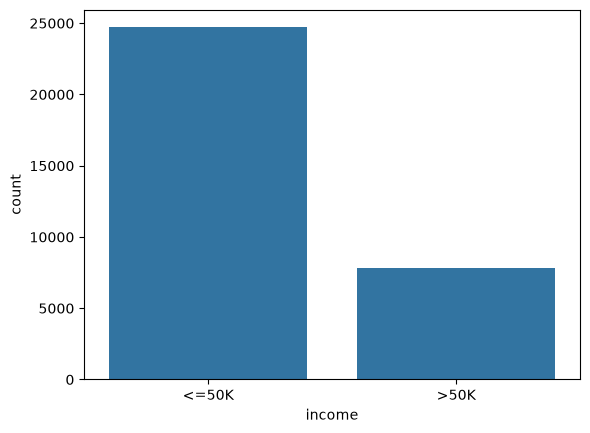

In [93]:
sns.countplot(x='income',data=df)

<Axes: xlabel='income', ylabel='age'>

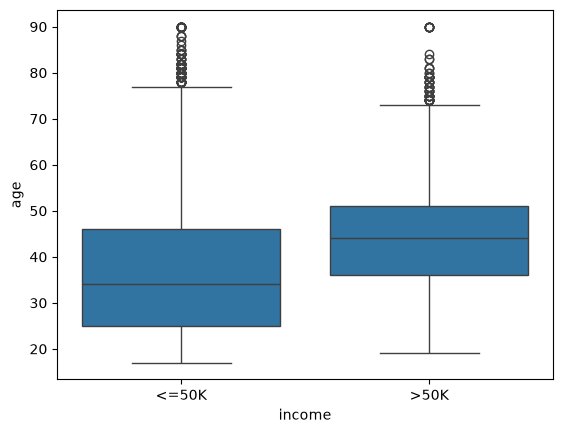

In [94]:
sns.boxplot(x='income', y='age', data=df)

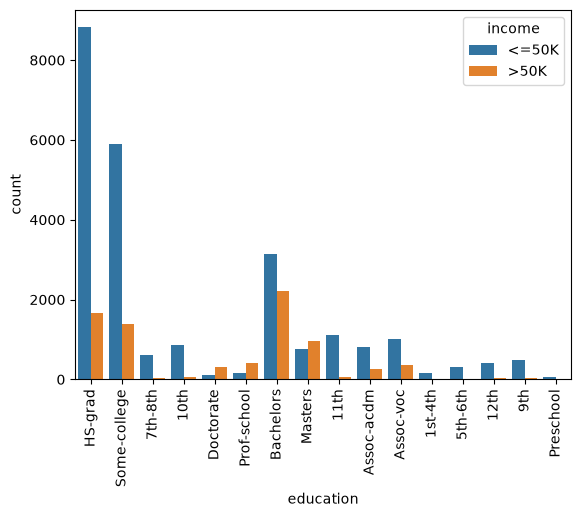

In [95]:
sns.countplot(data=df, x='education', hue='income')
plt.xticks(rotation=90)
plt.show()

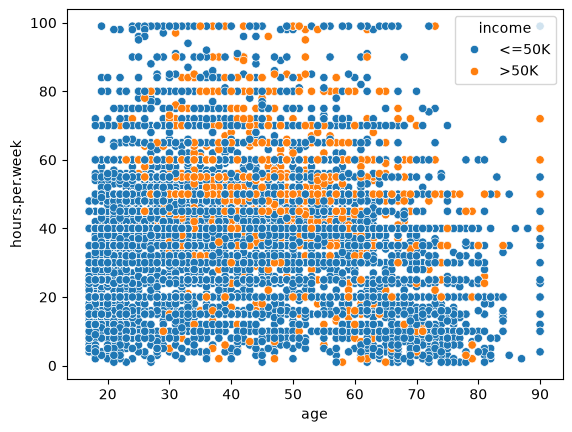

In [96]:
sns.scatterplot(data=df, x='age', y='hours.per.week', hue='income')
plt.show()

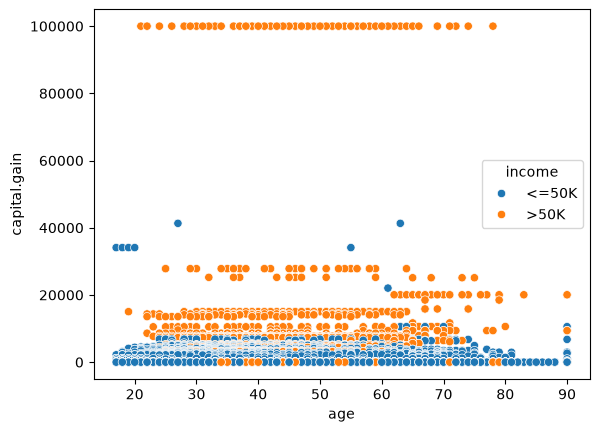

In [97]:
sns.scatterplot(
    data=df,
    x='age',
    y='capital.gain',
    hue='income'
)
plt.show()

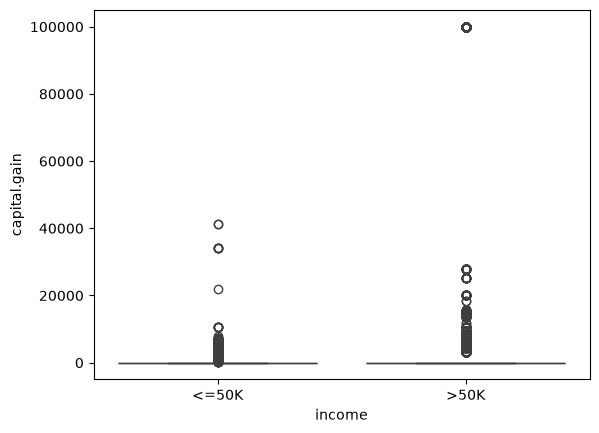

In [98]:
sns.boxplot(data=df, x='income', y='capital.gain')
plt.show()

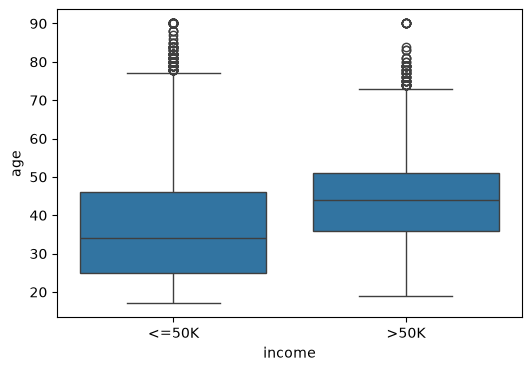

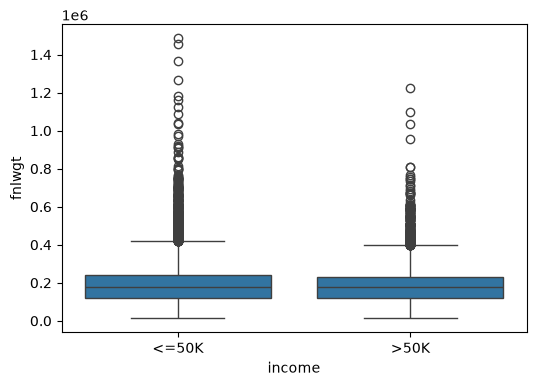

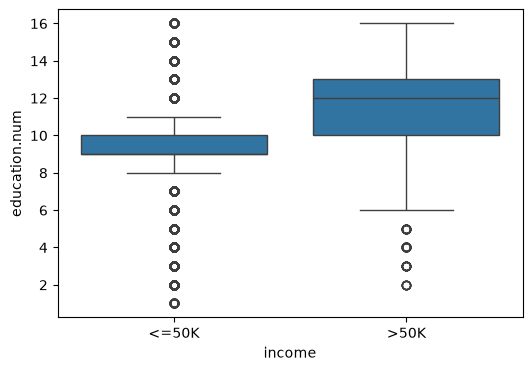

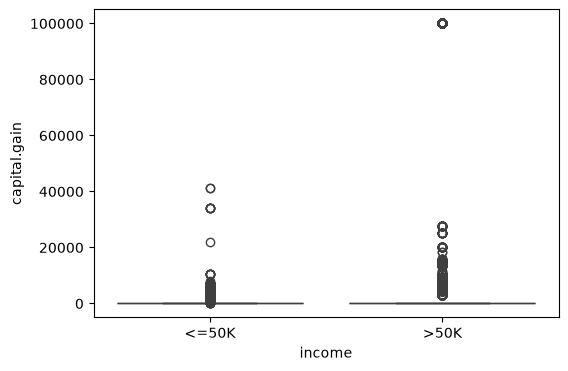

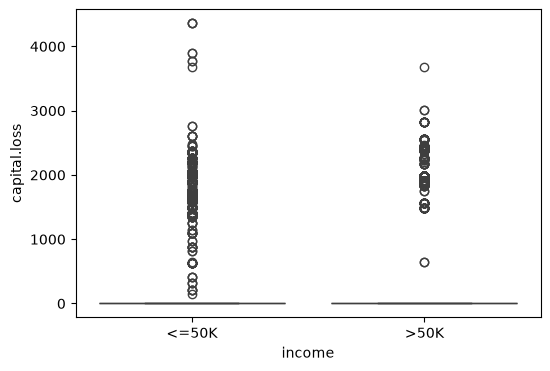

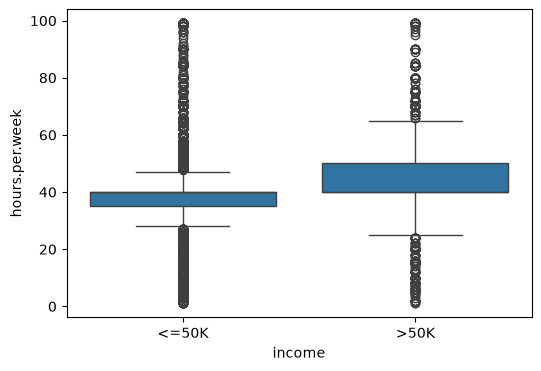

In [99]:
num_cols = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="income", y=col)
    plt.show()

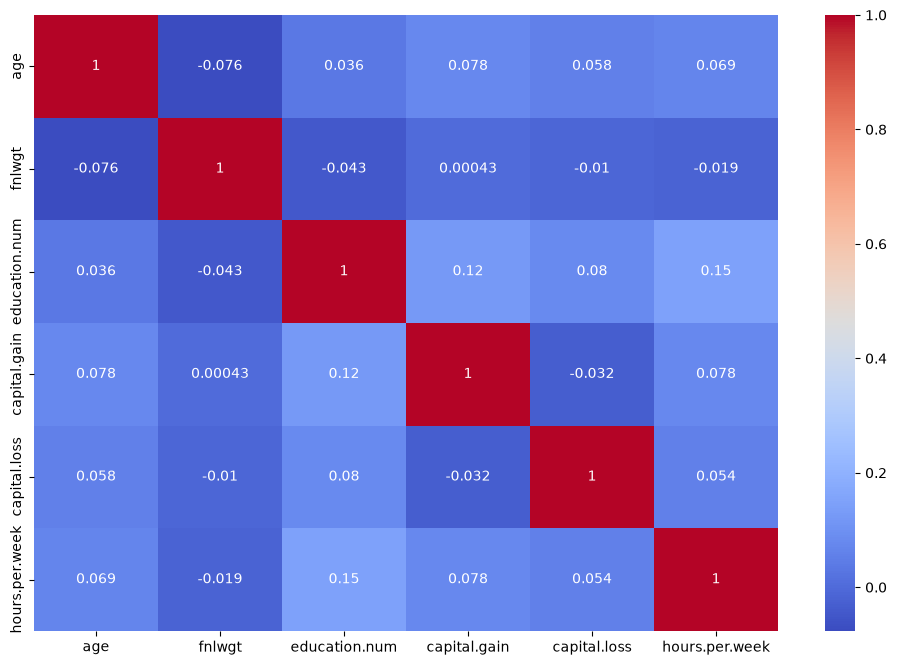

In [100]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [101]:
df.drop(columns='fnlwgt',inplace=True)
df.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


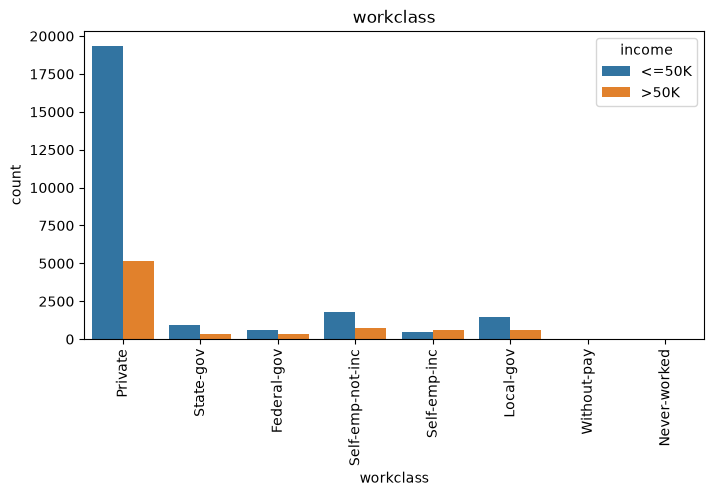

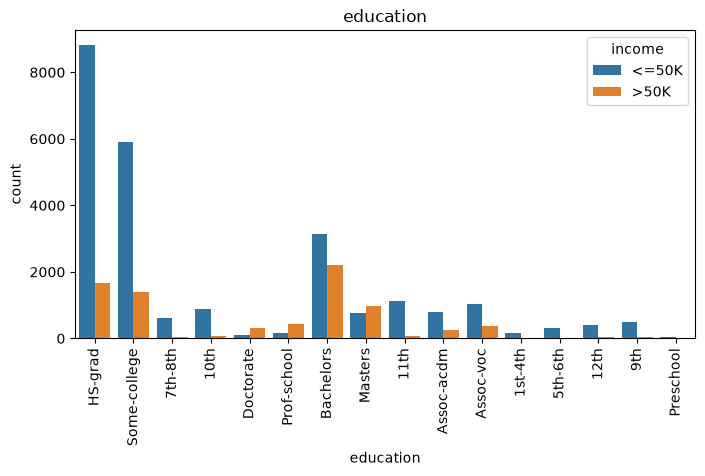

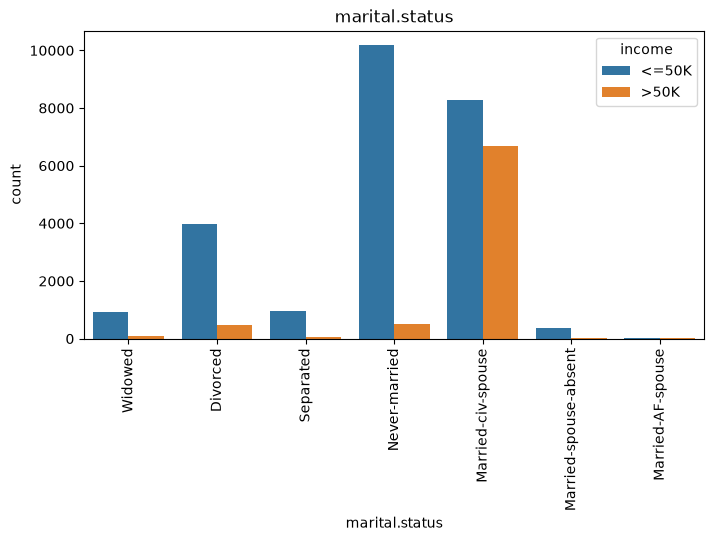

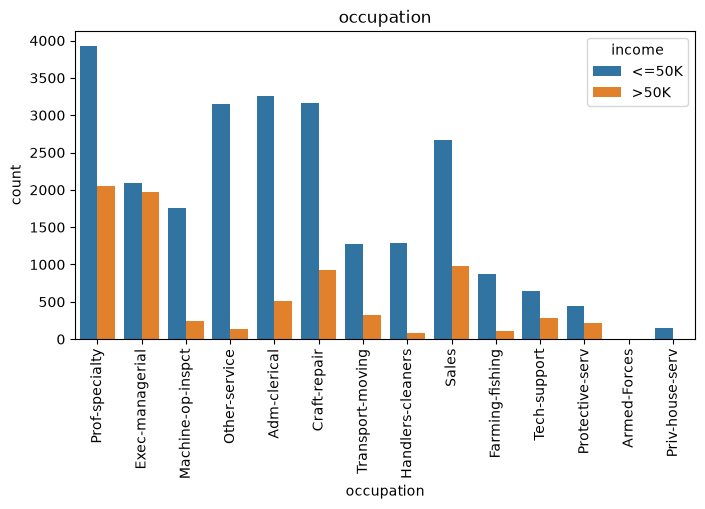

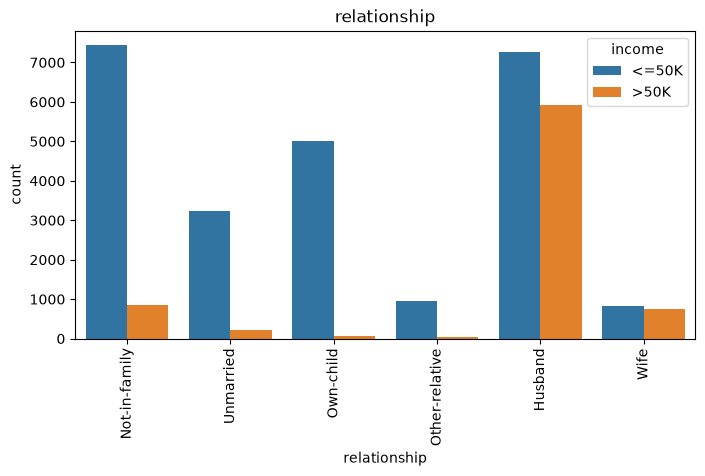

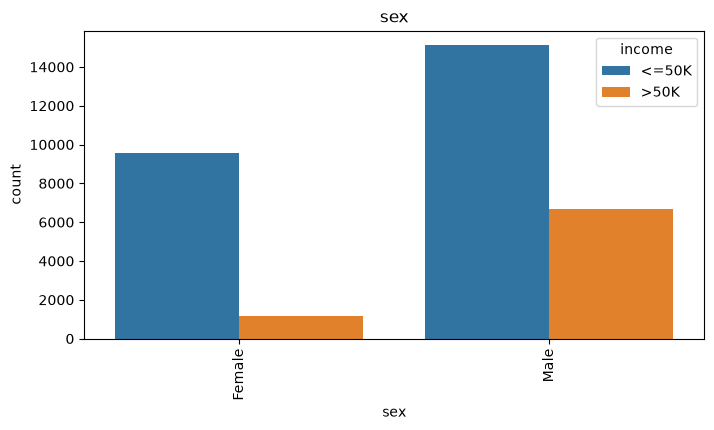

In [102]:
categorical_cols = [
    "workclass",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "sex"
]

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue="income")
    plt.xticks(rotation=90)
    plt.title(col)
    plt.show()

In [103]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ["income", "sex"]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [104]:
one_hot_cols = [
    "workclass",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "native.country"
]

df = pd.get_dummies(
    df,
    columns=one_hot_cols,
    drop_first=True,
    dtype=int
)
df.head()

,age,education.num,sex,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,9,0,0,4356,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,82,9,0,0,4356,18,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,66,10,0,0,4356,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,54,4,0,0,3900,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,41,10,0,0,3900,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [105]:
X = df.drop("income", axis=1)
y = df["income"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [109]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(random_state=42)
}
scaled_models = [
    "Logistic Regression",
    "KNN",
    "SVM"
]

In [115]:
result=[]

for name,model in models.items():
    if name in scaled_models:
        model.fit(X_train_scaled,y_train)
        prediction = model.predict(X_test_scaled)
        acc = accuracy_score(y_test,prediction)
        f1 = f1_score(y_test,prediction)
        precision = precision_score(y_test,prediction)
        recall = recall_score(y_test,prediction)
        result.append(
            {
                "name":name,
                "accuracy":acc,
                "f1 score":f1,
                "precision":pre,
                "recall":recall
                
            }
        )
    else:
        model.fit(X_train,y_train)
        prediction = model.predict(X_test)
        acc = accuracy_score(y_test,prediction)
        f1 = f1_score(y_test,prediction)
        pre = precision_score(y_test,prediction)
        recall = recall_score(y_test,prediction)
        result.append(
            {
                "name":name,
                "accuracy":acc,
                "f1 score":f1,
                "precision":pre,
                "recall":recall
                        
            }
        )
result

[{'name': 'Logistic Regression',
  'accuracy': 0.8497234173325138,
  'f1 score': 0.6556338028169014,
  'precision': 0.7711213517665131,
  'recall': 0.59375},
 {'name': 'KNN',
  'accuracy': 0.8214505224339275,
  'f1 score': 0.6044928522804629,
  'precision': 0.7711213517665131,
  'recall': 0.5663265306122449},
 {'name': 'Naive Bayes',
  'accuracy': 0.8228334357713584,
  'f1 score': 0.6585726976606455,
  'precision': 0.6147042564953012,
  'recall': 0.7091836734693877},
 {'name': 'Decision Tree',
  'accuracy': 0.8119237861094039,
  'f1 score': 0.6005221932114883,
  'precision': 0.6149732620320856,
  'recall': 0.5867346938775511},
 {'name': 'Random Forest',
  'accuracy': 0.8394283958205285,
  'f1 score': 0.6434663937222791,
  'precision': 0.6918561995597946,
  'recall': 0.6014030612244898},
 {'name': 'AdaBoost',
  'accuracy': 0.8492624462200369,
  'f1 score': 0.6446939514668598,
  'precision': 0.7460184409052808,
  'recall': 0.5676020408163265},
 {'name': 'SVM',
  'accuracy': 0.84219422249

In [122]:
pd.DataFrame(result).sort_values(by='recall',ascending=False)

,name,accuracy,f1 score,precision,recall
2,Naive Bayes,0.822833,0.658573,0.614704,0.709184
7,XGBoost,0.867548,0.699652,0.771121,0.640306
4,Random Forest,0.839428,0.643466,0.691856,0.601403
0,Logistic Regression,0.849723,0.655634,0.771121,0.593750
3,Decision Tree,0.811924,0.600522,0.614973,0.586735
5,AdaBoost,0.849262,0.644694,0.746018,0.567602
1,KNN,0.821451,0.604493,0.771121,0.566327
6,SVM,0.842194,0.622288,0.746018,0.539541


In [127]:
top_models = {
    "Logistic Regression": models["Logistic Regression"],
    "XGBoost": models["XGBoost"]
}



In [130]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in top_models.items():

    if name in scaled_models:
        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="f1"
        )
    else:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="f1"
        )

    cv_results.append({
        "Model": name,
        "Mean F1": scores.mean(),
        "Std": scores.std()
    })

In [131]:
pd.DataFrame(cv_results)

,Model,Mean F1,Std
0,Logistic Regression,0.656697,0.006470
1,XGBoost,0.714220,0.006273


In [140]:
from sklearn.model_selection import RandomizedSearchCV

param_lr = {
    "C": [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
    "max_iter": [500, 1000, 2000],
    "class_weight": [None, "balanced"]
}

param_xgb = {
    "n_estimators": [50, 100, 200, 300],

    "max_depth": [3, 5, 7, 9],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "subsample": [0.6, 0.8, 1.0],

    "colsample_bytree": [0.6, 0.8, 1.0],

    "gamma": [0, 0.1, 0.3, 0.5],

    "min_child_weight": [1, 3, 5],

    "reg_alpha": [0, 0.1, 1],

    "reg_lambda": [1, 5, 10],

    "scale_pos_weight": [1, 2, 3]
}

In [141]:
lr_clr = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=param_lr,
    n_iter=15,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

In [142]:
xgboost_clr = RandomizedSearchCV(
    XGBClassifier(random_state=42,n_jobs=-1,eval_metric="logloss"),
    param_distributions=param_xgb,
    n_iter=30,
    cv=3,
    scoring="f1",
    random_state=42,
)


In [143]:
lr_clr.fit(X_train_scaled,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'max_iter': [500, 1000, ...], 'penalty': ['l1', 'l2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluat

In [144]:
xgboost_clr.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for mu

In [146]:
print("LogisticRegression Best Parameters: ",lr_clr.best_params_)
print("LogisticRegression Best CV Score: ",lr_clr.best_score_)

print("XG-Boost Best Parameters: ",xgboost_clr.best_params_)
print("XG-Boost Best CV Score: ",xgboost_clr.best_score_)

LogisticRegression Best Parameters:  {'solver': 'saga', 'penalty': 'l2', 'max_iter': 500, 'class_weight': 'balanced', 'C': 1}
LogisticRegression Best CV Score:  0.6809543940741823
XG-Boost Best Parameters:  {'subsample': 1.0, 'scale_pos_weight': 2, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.6}
XG-Boost Best CV Score:  0.7280043114752849


In [ ]:
best_lr = lr_clr.best_estimator_
best_xgb = xgboost_clr.best_estimator_


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"C C: float, default=1.0Inverse of regularization strength; must be a p

In [150]:
lr_pred = best_lr.predict(X_test_scaled)
xgb_pred = best_xgb.predict(X_test)

In [151]:
print("========== Logistic Regression ==========\n")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, lr_pred))

========== Logistic Regression ==========

Accuracy : 0.8036263060848187
Precision: 0.5630434782608695
Recall   : 0.8258928571428571
F1 Score : 0.6695966907962771

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.80      0.86      4940
           1       0.56      0.83      0.67      1568

    accuracy                           0.80      6508
   macro avg       0.75      0.81      0.76      6508
weighted avg       0.85      0.80      0.81      6508


Confusion Matrix

[[3935 1005]
 [ 273 1295]]


In [153]:
print("========== XGBoost ==========\n")

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))

print("\nClassification Report\n")
print(classification_report(y_test, xgb_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, xgb_pred))

========== XGBoost ==========

Accuracy : 0.8538721573448064
Precision: 0.6677542142468733
Recall   : 0.7831632653061225
F1 Score : 0.7208687995303786

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.88      0.90      4940
           1       0.67      0.78      0.72      1568

    accuracy                           0.85      6508
   macro avg       0.80      0.83      0.81      6508
weighted avg       0.86      0.85      0.86      6508


Confusion Matrix

[[4329  611]
 [ 340 1228]]


In [154]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, xgb_pred)
    ]
})

comparison.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,XGBoost,0.853872,0.667754,0.783163,0.720869
0,Logistic Regression,0.803626,0.563043,0.825893,0.669597


<Figure size 1000x800 with 0 Axes>

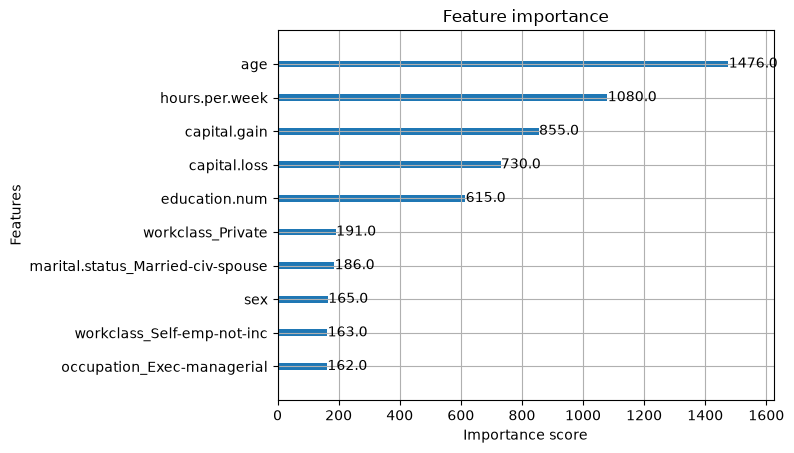

In [155]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plot_importance(best_xgb, max_num_features=10)
plt.show()